# Assignment 3: Time Series
#### Classifying Cardiac Arrhythmias: A Comparative Analysis

#### Authors:
- Michael George Nabih Lotfy Eskander
- David Hidalgo Fàbregas
- Miriam Iturralde Aguiló
- Pablo Longán Gasol
- Joao Constantino Muianga

#### Libraries:

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

import wfdb

## 1. Data Loading & Exploration

### 1.1. Load data

In [6]:
RECORDS = [
    "100", "101", "105", "106", "108", "109", "111",
    "112", "115", "117", "119", "201", "213", "219"
]

records_data = {}
for rec_id in RECORDS:
    record = wfdb.rdrecord(rec_id, pn_dir="mitdb") # Read the record from the MIT-BIH Arrhythmia Database
    ann = wfdb.rdann(rec_id, 'atr', pn_dir="mitdb") # Read the annotations for the record
    signal = record.p_signal[:, 0]  # Use the first channel (MLII)

    records_data[rec_id] = {
        "record": record,
        "ann": ann,
        "signal": signal
    }

record_summary = pd.DataFrame([
    {
        "record_id": rec_id,
        "n_samples": len(rec_obj["signal"]),
        "fs": rec_obj["record"].fs,
        "n_annotations": len(rec_obj["ann"].sample),
        "signal_shape": rec_obj["record"].p_signal.shape
    }
    for rec_id, rec_obj in records_data.items()
]).sort_values("record_id").reset_index(drop=True)

print(record_summary)

   record_id  n_samples   fs  n_annotations signal_shape
0        100     650000  360           2274  (650000, 2)
1        101     650000  360           1874  (650000, 2)
2        105     650000  360           2691  (650000, 2)
3        106     650000  360           2098  (650000, 2)
4        108     650000  360           1824  (650000, 2)
5        109     650000  360           2535  (650000, 2)
6        111     650000  360           2133  (650000, 2)
7        112     650000  360           2550  (650000, 2)
8        115     650000  360           1962  (650000, 2)
9        117     650000  360           1539  (650000, 2)
10       119     650000  360           2094  (650000, 2)
11       201     650000  360           2039  (650000, 2)
12       213     650000  360           3294  (650000, 2)
13       219     650000  360           2312  (650000, 2)


### 1.2. Plot 5-second segment

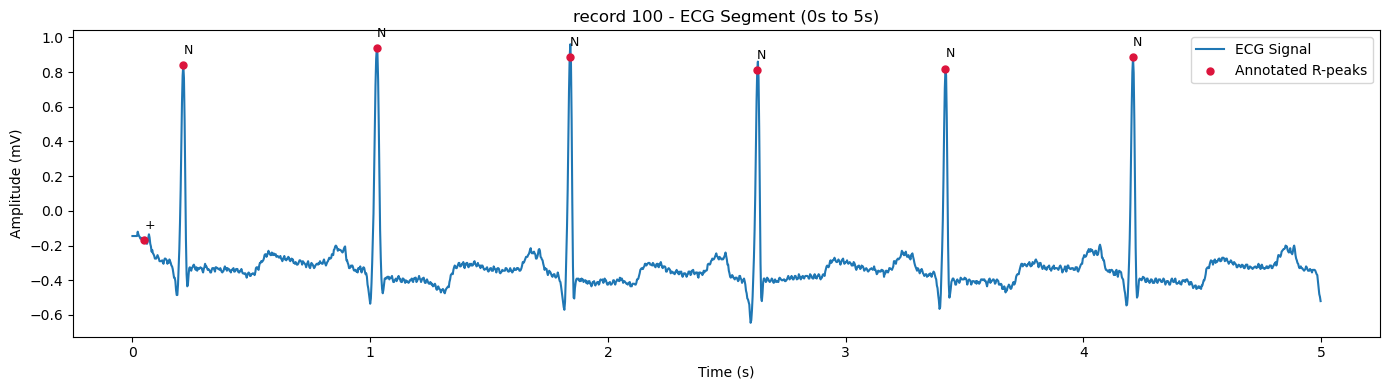

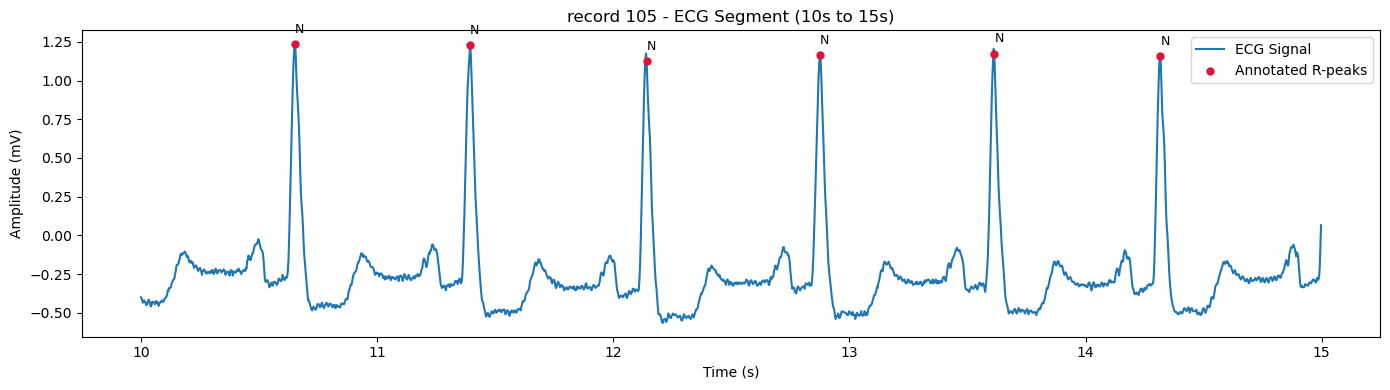

In [7]:
def plot_ecg_segment(rec_data, rec_id, start_sec=0, duration_sec=5):

    rec_obj = rec_data[rec_id]

    signal = rec_obj["signal"]
    ann = rec_obj["ann"]
    fs = rec_obj["record"].fs

    start_idx = int(start_sec*fs)
    end_idx = int((start_sec + duration_sec)*fs)

    seg_signal = signal[start_idx:end_idx]
    seg_time = np.arange(start_idx, end_idx) / fs

    mask = (ann.sample >= start_idx) & (ann.sample < end_idx)
    peak_samples = ann.sample[mask]
    peak_symbols = np.array(ann.symbol)[mask]

    plt.figure(figsize=(14,4))
    plt.plot(seg_time, seg_signal, label="ECG Signal")
    plt.scatter(
        peak_samples / fs,
        signal[peak_samples],
        color="crimson",
        s=25,
        zorder=3,
        label="Annotated R-peaks"
    )

    for s, sym in zip(peak_samples, peak_symbols):
        text = f"{sym}"
        plt.annotate(
            text,
            (s/fs, signal[s]),
            textcoords="offset points",
            xytext=(0,8),
            fontsize=9
        )

    plt.title(f"record {rec_id} - ECG Segment ({start_sec}s to {start_sec + duration_sec}s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_ecg_segment(records_data, "100", start_sec=0, duration_sec=5)
plot_ecg_segment(records_data, "105", start_sec=10, duration_sec=5)


### 1.3. Label mapping

In [8]:
LABEL_MAP = {
    # N — Normal
    "N": "N", ".": "N", "L": "N", "R": "N", "e": "N", "j": "N",
    # S — Supraventricular ectopic
    "A": "S", "a": "S", "J": "S", "S": "S",
    # V — Ventricular ectopic
    "V": "V", "E": "V"
}

mapped_rows = []
discard_rows = []

for rec_id, rec_obj in records_data.items():
    ann = rec_obj["ann"]
    for sample, symbol in zip(ann.sample, ann.symbol):

        if symbol in LABEL_MAP:
            mapped_rows.append({
                "record_id": rec_id,
                "sample": int(sample),
                "symbol": symbol,
                "label": LABEL_MAP.get(symbol, "Unknown")
            })

        else:
            discard_rows.append({
                "record_id": rec_id,
                "sample": int(sample),
                "symbol": symbol
            })

mapped_beats = pd.DataFrame(mapped_rows)
discarded_beats = pd.DataFrame(discard_rows)

if not discarded_beats.empty:
    discarded_by_symbol = (
        discarded_beats.groupby("symbol")
        .size()
        .sort_values(ascending=False)
        .reset_index(name="count")
    )
    discarded_by_record_symbol = (
        discarded_beats.groupby(["record_id", "symbol"])
        .size()
        .sort_values(ascending=False)
        .reset_index(name="count")
    )

    print("\nDiscarded counts by raw symbol:")
    print(discarded_by_symbol.head(20))
    print("Total discarded annotations:", len(discarded_beats))


Discarded counts by raw symbol:
  symbol  count
0      F    369
1      +    252
2      ~    196
3      x    181
4      |     48
5      Q      7
6      "      4
Total discarded annotations: 1057


### 1.4. Class distribution

  class  count  percentage (%)
0     N  28412           94.20
1     S    206            0.68
2     V   1544            5.12
Total mapped beats: 30162


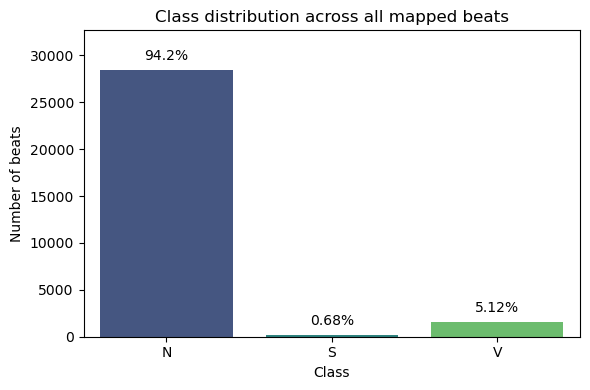

In [9]:
class_counts = (
    mapped_beats["label"]
    .value_counts()
    .reindex(["N", "S", "V"], fill_value=0)
    .rename_axis("class")
    .reset_index(name="count")
)

total_beats = len(mapped_beats)
class_counts["percentage (%)"] = (class_counts["count"] / total_beats * 100).round(2)

print(class_counts)
print("Total mapped beats:", len(mapped_beats))

plt.figure(figsize=(6, 4))
ax =sns.barplot(data=class_counts, x="class", y="count", hue="class", palette="viridis")
plt.title("Class distribution across all mapped beats")
plt.xlabel("Class")
plt.ylabel("Number of beats")
max_count = class_counts["count"].max()
ax.set_ylim(0, max_count * 1.15)

row_idx = 0
for p in ax.patches:
    height = p.get_height()
    
    if height > 0:
        pct_value = class_counts.iloc[row_idx]["percentage (%)"]
        percentage_text = f'{pct_value}%'
        # Colocamos el texto justo en el centro superior de cada barra
        ax.annotate(percentage_text, 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black', 
                    xytext=(0, 5), textcoords='offset points')
        row_idx += 1
        
plt.tight_layout()
plt.show()


The MIT-BIH dataset exhibits severe class imbalance, with N beats comprising ~95% of all beats. S and V beats together account for only 5%.

Implications for modelling:

- A naïve classifier predicting 'N' always would achieve ~87% accuracy a misleading metric that masks total failure on clinically critical classes.
- False negatives on V (ventricular ectopic) beats are especially dangerous: missing a PVC or ventricular escape beat can have fatal consequences.
- Recommended metrics:
  - Macro-averaged F1: treats every class equally regardless of size.
  - Per-class recall for S and V: directly measures sensitivity to rare events.
  - Weighted F1 gives a secondary picture (overall balance).

## 2. Preprocessing & Feature Engineering

### 2.2. Feature extraction

In [10]:
mapped_beats[mapped_beats["record_id"] == "100"]

,record_id,sample,symbol,label
0,100,77,N,N
1,100,370,N,N
2,100,662,N,N
3,100,946,N,N
4,100,1231,N,N
...,...,...,...,...
2268,100,648978,N,N
2269,100,649232,N,N
2270,100,649484,N,N
2271,100,649734,N,N


In [11]:
summary_id = record_summary[record_summary["record_id"] == "100"]
summary_id

,record_id,n_samples,fs,n_annotations,signal_shape
0,100,650000,360,2274,"(650000, 2)"


In [12]:
def extract_features(rec_id, beats_id):
    """
    Compute the 8 physical features for each valid heartbeat in a specific record.
    """
    print(f"-> Processing record {rec_id} with {len(beats_id)} beats...")

    # Original record data
    record = wfdb.rdrecord(str(rec_id), pn_dir="mitdb")
    signal = record.p_signal[:, 0]  # Channel 0 (MLII)
    fs = record.fs # Sampling frequency (360 Hz)

    # Extract peak indexes
    peaks_idx = beats_id["sample"].values
    n_beats = len(peaks_idx)

    # --- A. Temporal features: RR invervals (in ms) ---
    rr_intervals = np.diff(peaks_idx) / fs * 1000  # Convert to ms

    rr_current = np.zeros(n_beats) # 1. RR interval of current beat
    rr_prev = np.zeros(n_beats) # 2. RR interval of previous beat
    rr_local_mean = np.zeros(n_beats) # 3. Local moving average of RR intervals (last 5 beats)
    rr_ratio = np.zeros(n_beats) # 4. Ratio of current RR to previous RR (RR_current / RR_previous)

    # Handling "First beat edge case"
    # The mean of the first 5 available intervals in the record is used.
    initial_mean_rr = np.mean(rr_intervals[:5]) if len(rr_intervals) >= 5 else np.mean(rr_intervals)
    for i in range(n_beats):
        if i == 0:
            rr_current[i] = initial_mean_rr
            rr_prev[i] = initial_mean_rr
            rr_local_mean[i] = initial_mean_rr
        elif i == 1:
            rr_current[i] = rr_intervals[i-1]
            rr_prev[i] = initial_mean_rr
            rr_local_mean[i] = np.mean([initial_mean_rr, rr_intervals[i-1]])
        else:
            rr_current[i] = rr_intervals[i-1]
            rr_prev[i] = rr_intervals[i-2]
            # Local moving average of last 5 beats (beats i-4 to i)
            window_intervals = rr_intervals[max(0, i-4):i]  # Get last 5 intervals (or fewer if at the start)
            rr_local_mean[i] = np.mean(window_intervals)
        
        rr_ratio[i] = rr_current[i] / rr_prev[i] if rr_prev[i] != 0 else 0
    

    # --- B. Morphological and Repolarization Features ---
    r_amplitude = np.zeros(n_beats)
    qrs_duration = np.zeros(n_beats)
    qrs_energy = np.zeros(n_beats)
    st_mean = np.zeros(n_beats)

    for i, r_idx in enumerate(peaks_idx):
        # 5. R-peak amplitude: Signal value at R-peak
        r_amplitude[i] = signal[r_idx]
        # 6. QRS duration: Width of QRS complex (above 50% of R-peak amplitude)
        threshold = 0.5 * r_amplitude[i]
        left_idx = r_idx
        while left_idx > 0 and signal[left_idx] > threshold:
            left_idx -= 1
            if (r_idx - left_idx) > 100: # Safety threshold against noise
                break
        right_idx = r_idx
        while right_idx < len(signal) and signal[right_idx] > threshold:
            right_idx += 1
            if (right_idx - r_idx) > 100: # Safety threshold against noise
                break
        qrs_duration[i] = (right_idx - left_idx) / fs * 1000  # Duration in ms
        # 7. QRS energy: Sum of squared amplitudes within a +/- 20-sample window
        qrs_start = max(0, r_idx - 20)
        qrs_end = min(len(signal), r_idx + 21) # +21 to include the 20th sample
        qrs_energy[i] = np.sum(signal[qrs_start:qrs_end] ** 2)
        # 8. ST mean: Mean signal value in the ST segment (+40 to +120 samples post-R)
        st_start = min(len(signal), r_idx + 40)
        st_end = min(len(signal), r_idx + 121) # +121 to include the 120th sample
        st_mean[i] = np.mean(signal[st_start:st_end]) if st_end > st_start else 0

    rec_features = beats_id.copy()
    rec_features["RR_current"] = rr_current
    rec_features["RR_prev"] = rr_prev
    rec_features["RR_ratio"] = rr_ratio
    rec_features["RR_local_mean"] = rr_local_mean
    rec_features["R_amplitude"] = r_amplitude
    rec_features["QRS_duration"] = qrs_duration
    rec_features["QRS_energy"] = qrs_energy
    rec_features["ST_mean"] = st_mean

    return rec_features

In [13]:
features = []
for rec_id in RECORDS:
    beats_id = mapped_beats[mapped_beats["record_id"] == rec_id]
    features_id = extract_features(rec_id, beats_id)
    features.append(features_id)

features_df = pd.concat(features, ignore_index=True)
print(f" Shape of features_df: {features_df.shape}")

-> Processing record 100 with 2273 beats...
-> Processing record 101 with 1863 beats...
-> Processing record 105 with 2567 beats...
-> Processing record 106 with 2027 beats...
-> Processing record 108 with 1761 beats...
-> Processing record 109 with 2530 beats...
-> Processing record 111 with 2124 beats...
-> Processing record 112 with 2539 beats...
-> Processing record 115 with 1953 beats...
-> Processing record 117 with 1535 beats...
-> Processing record 119 with 1987 beats...
-> Processing record 201 with 1961 beats...
-> Processing record 213 with 2889 beats...
-> Processing record 219 with 2153 beats...
 Shape of features_df: (30162, 12)


### 2.3. Train/test split

In [46]:
FEATURES = ['RR_current', 'RR_prev', 'RR_ratio', 'RR_local_mean', 
            'R_amplitude', 'QRS_duration', 'QRS_energy', 'ST_mean']

X = features_df[FEATURES]
y = features_df["label"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### 2.4. Scaling

In [47]:
# Adjusting the features to have zero mean and unit variance (standardization)
# Adjust only with training data to prevent data leakage,
# then apply the same transformation to the test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURES, index=X_train_raw.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=FEATURES, index=X_test_raw.index)

### 2.5. Sliding Window Dataset

In [48]:
X_train, y_train = [], []
X_test, y_test = [], []

# Group data by patient to avoid mixing data
for record_id, group in features_df.groupby("record_id"):
    X_group = group[FEATURES].values
    y_group = group["label"].values
    idx_group = group.index.values

    if len(X_group) >= 10:
        for i in range(9, len(X_group)):
            window = X_group[i-9:i+1]  # 10-beat window (T=10)
            label = y_group[i]  # final beat label
            actual_idx = idx_group[i] # Index in the original DataFrame
            
            # Decide whether to put this window in train or test based on the original index
            if actual_idx in X_train_scaled.index:
                X_train.append(window)
                y_train.append(label)
            elif actual_idx in X_test_scaled.index:
                X_test.append(window)
                y_test.append(label)

# Sincse we are using windows (3D), we need to use numpy arrays instead of pandas.
X_train, y_train = np.array(X_train), np.array(y_train)
X_test, y_test = np.array(X_test), np.array(y_test)

#### Class Balance Checking

In [69]:
def class_balance(y_set, set_name):
    counts = pd.Series(y_set).value_counts()
    props = pd.Series(y_set).value_counts(normalize=True) * 100
    print(f"--- Class distribution in: {set_name} ---")
    for cls in ['N', 'S', 'V']:
        if cls in counts.index:
            print(f"  Class {cls}: {counts[cls]:>6} beats ({props[cls]:.2f}%)")
    print(f"  Total: {len(y_set)} beats\n")


In [78]:
print("================================")
print("CHECKING DIVISIONS (SINGLE BEAT)")
print("================================")
class_balance(y_train_raw, "Training Set (Single Beat)")
class_balance(y_test_raw, "Test Set (Single Beat)")
print(f"Train/Test split: {len(y_train_raw) / (len(y_train_raw) + len(y_test_raw)) * 100:.2f}%")

CHECKING DIVISIONS (SINGLE BEAT)
--- Class distribution in: Training Set (Single Beat) ---
  Class N:  22729 beats (94.20%)
  Class S:    165 beats (0.68%)
  Class V:   1235 beats (5.12%)
  Total: 24129 beats

--- Class distribution in: Test Set (Single Beat) ---
  Class N:   5683 beats (94.20%)
  Class S:     41 beats (0.68%)
  Class V:    309 beats (5.12%)
  Total: 6033 beats

Train/Test split: 80.00%


In [79]:
print("==================================================")
print("CHECKING DIVISIONS (SLIDING WINDOWS - CORRECTED)")
print("==================================================")
print(f"Shape of X_train_w: {X_train.shape} -> (Samples, T={X_train.shape[1]}, Features={X_train.shape[2]})")
print(f"Shape of X_test_w:  {X_test.shape} -> (Samples, T={X_test.shape[1]}, Features={X_test.shape[2]})\n")
class_balance(y_train, "Train Set (Sliding Windows)")
class_balance(y_test, "Test Set (Sliding Windows)")
print(f"Train/Test split: {len(y_train) / (len(y_train) + len(y_test)) * 100:.2f}%")

CHECKING DIVISIONS (SLIDING WINDOWS - CORRECTED)
Shape of X_train_w: (24027, 10, 8) -> (Samples, T=10, Features=8)
Shape of X_test_w:  (6009, 10, 8) -> (Samples, T=10, Features=8)

--- Class distribution in: Train Set (Sliding Windows) ---
  Class N:  22628 beats (94.18%)
  Class S:    165 beats (0.69%)
  Class V:   1234 beats (5.14%)
  Total: 24027 beats

--- Class distribution in: Test Set (Sliding Windows) ---
  Class N:   5661 beats (94.21%)
  Class S:     40 beats (0.67%)
  Class V:    308 beats (5.13%)
  Total: 6009 beats

Train/Test split: 79.99%


### 2.6. Feature Correlation Heatmap

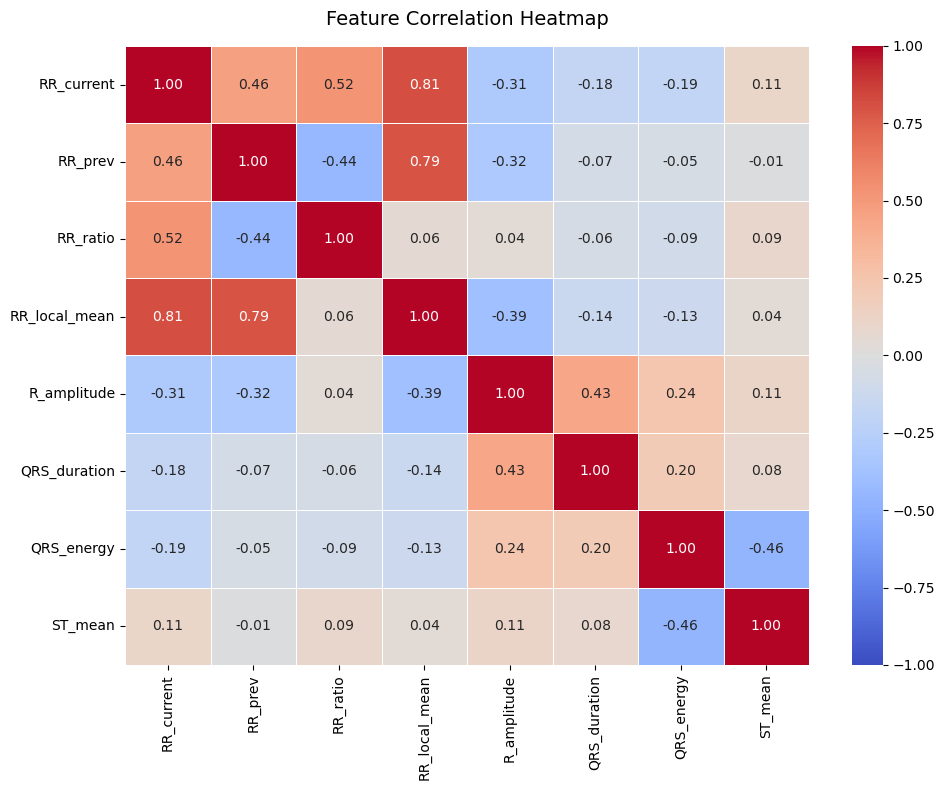

In [83]:
corr_matrix = X_train_raw.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    annot=True,         # Show correlation values in the cells 
    cmap='coolwarm',    # Color map for better visualization of positive/negative correlations
    fmt=".2f",          # Format for annotation (2 decimal places)
    vmin=-1, vmax=1,    # Set limits for the color scale
    linewidths=0.5,     # Add lines between cells for better readability
)

plt.title("Feature Correlation Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

**RR_local_mean vs RR_current/RR_prev (0.81 and 0.79):**  
This is the highest correlation, which makes sense. Since the local mean is calculated based on the current and previous heartbeats, it is normal for them to be so highly correlated.

**No extreme correlations (> 0.95):**  
Since there are no variables with an extremly high correlation value (off the diagonal), this means there is no severe multicollinearity. All the features provide valuable information, and none of them is redundant.

## 3. Sequence Classification

### 3.1. Label encoding

It can be done using LabelEncoder() but, as there are only 3 classes, we can do it manually.

### 3.2. PyTorch Tensors

### 3.3. PyTorch Dataset and DataLoader

### 3.4. Epoch Training / Validation function

### 3.4. Recurrent Neural Network (RNN)

#### Architecture

#### Initialization

#### Training and Validation

#### Classification Report

#### Confusion Matrix

### 3.5. Long Short-Term Memory (LSTM) Architecture

#### Architecture

#### Initialization

#### Training and Validation

#### Classification Report

#### Confusion Matrix

## 4. Model Comparison & Evaluation

### 4.1. Summary Table

### 4.2. Discussion